# X1-S5: 파일럿 설계서 — 실습 과제 모범 답안
> KOREATECH 제조AI 교육과정 v1.6.15 | 교수자 배포용

## 과제 A (필수): 자신의 현장 문제 정의 (용접 공정 예시)

In [1]:
problems = [
    {'현상': '매월 용접 불량 15건 (불량률 2.5%)',
     '원인': '전류·전압 변동으로 용접 깊이 불균일',
     '목표': '센서 모니터링 AI → 불량률 1.0% 이하'},
    {'현상': '용접 후 X-Ray 검사 기공 불량 10%',
     '원인': '용접 속도 과다로 가스 미방출',
     '목표': '속도 최적화 모델 → 기공 불량 5% 미만'},
    {'현상': '월 평균 3건 용접 로봇 비계획 정지',
     '원인': '토치 마모 미감지로 갑작스런 고장',
     '목표': '예지보전 모델 → 비계획 정지 0건'},
]
for i, p in enumerate(problems, 1):
    print(f"[문제 {i}]")
    for k, v in p.items():
        print(f"  {k}: {v}")
    print()


[문제 1]
  현상: 매월 용접 불량 15건 (불량률 2.5%)
  원인: 전류·전압 변동으로 용접 깊이 불균일
  목표: 센서 모니터링 AI → 불량률 1.0% 이하

[문제 2]
  현상: 용접 후 X-Ray 검사 기공 불량 10%
  원인: 용접 속도 과다로 가스 미방출
  목표: 속도 최적화 모델 → 기공 불량 5% 미만

[문제 3]
  현상: 월 평균 3건 용접 로봇 비계획 정지
  원인: 토치 마모 미감지로 갑작스런 고장
  목표: 예지보전 모델 → 비계획 정지 0건



## 과제 B (필수): ROI 파라미터 2개 수정 후 재계산

=== 기존 파라미터 ===
  월 고장 빈도: 5건, 시간당 손실: 500,000원
  연간 사후정비 비용: 240.0백만원
  ROI: 1580.0%

=== 수정 파라미터 (과제 B) ===
  월 고장 빈도: 3건, 시간당 손실: 800,000원
  연간 사후정비 비용: 187.2백만원
  ROI: 1210.4%

→ 고장 빈도가 줄었지만 손실 단가 증가로 ROI 변화 확인


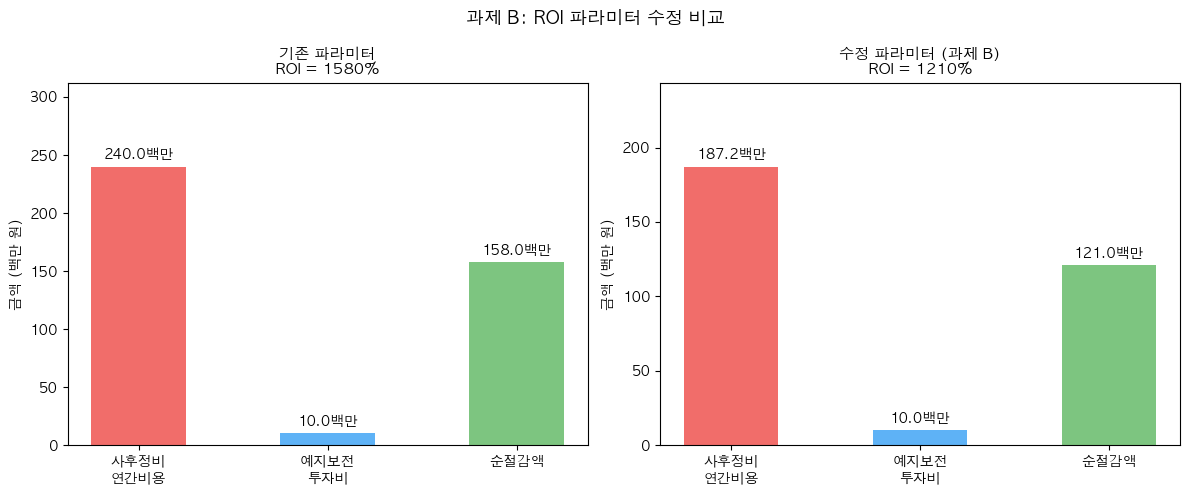

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

def calculate_roi(failure_per_month, loss_per_hour,
                  repair_cost=2_000_000, annual_invest=10_000_000, downtime_hrs=4):
    annual_failure_cost = failure_per_month * 12 * (loss_per_hour * downtime_hrs + repair_cost)
    savings = annual_failure_cost * 0.70
    net_savings = savings - annual_invest
    roi = net_savings / annual_invest * 100
    return dict(cost=annual_failure_cost, savings=savings, net=net_savings, roi=roi)

# 기존 파라미터
r_orig = calculate_roi(failure_per_month=5, loss_per_hour=500_000)

# 과제 B: 파라미터 2개 수정 (월 고장빈도 5→3건, 시간당 손실 50→80만원)
r_new  = calculate_roi(failure_per_month=3, loss_per_hour=800_000)

print("=== 기존 파라미터 ===")
print(f"  월 고장 빈도: 5건, 시간당 손실: 500,000원")
print(f"  연간 사후정비 비용: {r_orig['cost']/1e6:.1f}백만원")
print(f"  ROI: {r_orig['roi']:.1f}%")
print()
print("=== 수정 파라미터 (과제 B) ===")
print(f"  월 고장 빈도: 3건, 시간당 손실: 800,000원")
print(f"  연간 사후정비 비용: {r_new['cost']/1e6:.1f}백만원")
print(f"  ROI: {r_new['roi']:.1f}%")
print()
print(f"→ 고장 빈도가 줄었지만 손실 단가 증가로 ROI 변화 확인")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, r, title in zip(axes, [r_orig, r_new], ['기존 파라미터', '수정 파라미터 (과제 B)']):
    items = ['사후정비\n연간비용', '예지보전\n투자비', '순절감액']
    vals  = [r['cost']/1e6, 10, r['net']/1e6]
    cols  = ['#ef5350', '#42a5f5', '#66bb6a']
    bars  = ax.bar(items, vals, color=cols, alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='%.1f백만', fontsize=10, padding=3)
    ax.set_title(f'{title}\nROI = {r["roi"]:.0f}%', fontsize=11)
    ax.set_ylabel('금액 (백만 원)')
    ax.set_ylim(0, max(vals) * 1.3)
plt.suptitle('과제 B: ROI 파라미터 수정 비교', fontsize=13)
plt.tight_layout()
plt.show()


## 과제 C (심화): 3개월 파일럿 계획

3개월 파일럿 계획:

[1개월차]
  ▶ 용접 공정 센서 데이터 수집 시작 (전류·전압·속도 100Hz)
  ▶ 현장 작업자 인터뷰 및 불량 발생 조건 파악

[2개월차]
  ▶ 이상 탐지 모델 학습 (Isolation Forest)
  ▶ 정확도 검증 및 임계값 조정 (현장 피드백 반영)

[3개월차]
  ▶ 파일럿 결과 리포트 작성 (ROI 실측)
  ▶ 본사업 확산 의사결정 준비 및 발표


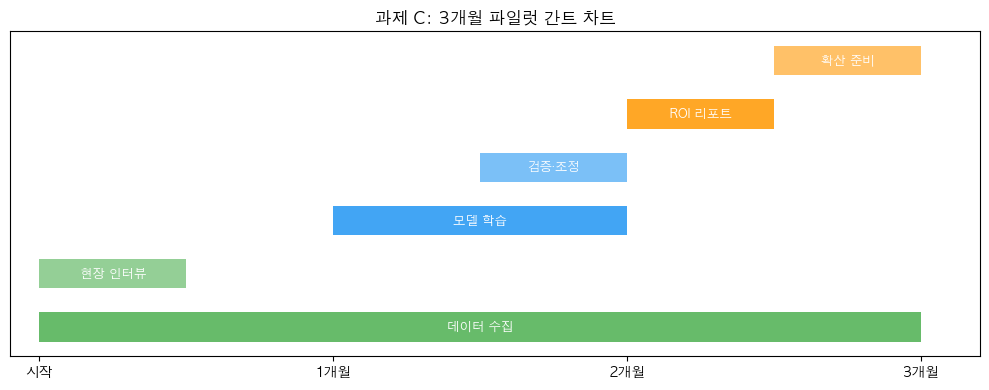

In [3]:
pilot_plan = {
    '1개월차': ['용접 공정 센서 데이터 수집 시작 (전류·전압·속도 100Hz)',
               '현장 작업자 인터뷰 및 불량 발생 조건 파악'],
    '2개월차': ['이상 탐지 모델 학습 (Isolation Forest)',
               '정확도 검증 및 임계값 조정 (현장 피드백 반영)'],
    '3개월차': ['파일럿 결과 리포트 작성 (ROI 실측)',
               '본사업 확산 의사결정 준비 및 발표'],
}

import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
import matplotlib.pyplot as plt

print("3개월 파일럿 계획:")
for month, tasks in pilot_plan.items():
    print(f"\n[{month}]")
    for t in tasks:
        print(f"  ▶ {t}")

# 간트 차트
fig, ax = plt.subplots(figsize=(10, 4))
activities = ['데이터 수집', '현장 인터뷰', '모델 학습', '검증·조정', 'ROI 리포트', '확산 준비']
starts  = [0, 0, 1, 1.5, 2, 2.5]
durations = [3, 0.5, 1, 0.5, 0.5, 0.5]
colors  = ['#4caf50','#81c784','#2196f3','#64b5f6','#ff9800','#ffb74d']
for i, (act, s, d, c) in enumerate(zip(activities, starts, durations, colors)):
    ax.barh(i, d, left=s, color=c, alpha=0.85, height=0.55)
    ax.text(s+d/2, i, act, ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['시작', '1개월', '2개월', '3개월'])
ax.set_yticks([])
ax.set_title('과제 C: 3개월 파일럿 간트 차트', fontsize=12)
ax.set_xlim(-0.1, 3.2)
plt.tight_layout()
plt.show()
